3.999921244813101 8.624938261370119e-07
(1624977,)
(1190306,)
(1624977,)
(1480828,)


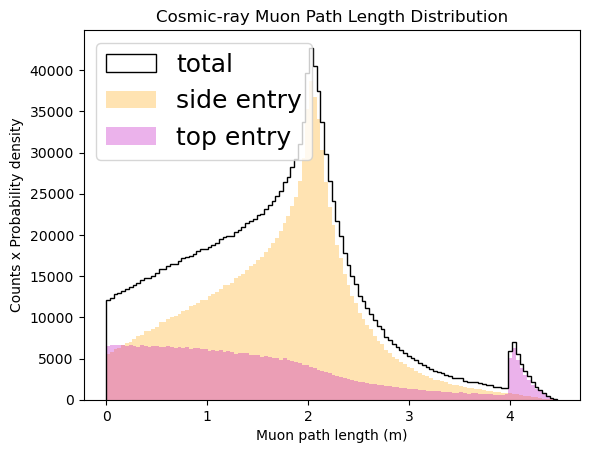

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Detector geometry
# ----------------------------
R = 1.0
Rwide = 10*R
H = 4
a = 1.3
N = 100_000_000 # easily scalable to 10M+

# ----------------------------
# Entry points (top surface)
# ----------------------------
r = Rwide * np.sqrt(np.random.rand(N))
phi = 2*np.pi*np.random.rand(N)

x0 = r*np.cos(phi)
y0 = r*np.sin(phi)
z0 = np.full(N, H/2)

# ----------------------------
# Cosmic-ray angular distribution
# approx cos^2(theta)
# ----------------------------
theta = np.arccos(np.random.rand(N))
phi_dir = 2*np.pi*np.random.rand(N)

accept = np.random.rand(N) < np.power(np.cos(theta),a)
theta = theta[accept]
phi_dir = phi_dir[accept]

x0 = x0[accept]
y0 = y0[accept]
z0 = z0[accept]

# direction vectors
vx = np.sin(theta)*np.cos(phi_dir)
vy = np.sin(theta)*np.sin(phi_dir)
vz = -np.cos(theta)

# ----------------------------
# Cylinder wall intersection
# ----------------------------
a = vx**2 + vy**2
b = 2*(x0*vx + y0*vy)
c = x0**2 + y0**2 - R**2

disc = b**2 - 4*a*c
disc[disc < 0] = np.nan

t1 = (-b + np.sqrt(disc))/(2*a)
t2 = (-b - np.sqrt(disc))/(2*a)


#make vector for muons hitting INSIDE R
cIn = (r[accept]<=R)
t1_in = t1[~np.isnan(t1)&(cIn)]
t2_in = t2[~np.isnan(t2)&(cIn)]

#print(np.min(t1_out*t2_out))
#print(np.max(t1_in*t2_in))
#print(np.min(t1_out),np.max(t1_out))
#print(np.min(t2_out),np.max(t2_out))

# keep forward solutions
#t_side = np.where((t1 > 0) & (t1 < t2), t1, t2)
t_side_in = np.where((t1_in > 0), t1_in, t2_in)


# ----------------------------
# Bottom cap intersection
# ----------------------------
t_bottom_in = (-H/2 - z0[cIn])/vz[cIn]
t_bottom_in[t_bottom_in <= 0] = np.nan


# ----------------------------
# Choose first exit
# ----------------------------
t_exit_in = np.nanmin(np.vstack([t_side_in, t_bottom_in]), axis=0)

# path lengths

#vnorm = np.sqrt(vx**2 + vy**2 + vz**2)

lengths_in = t_exit_in

# remove NaNs
lengths_in = lengths_in[np.isfinite(lengths_in)]


#make vector for muons hitting OUTSIDE R
t1_out = t1[~np.isnan(t1)&(~cIn)&(t1>0)]
t2_out = t2[~np.isnan(t2)&(~cIn)&(t1>0)]

x0_out = x0[~np.isnan(t1)&(~cIn)&(t1>0)]
y0_out = y0[~np.isnan(t1)&(~cIn)&(t1>0)]
vx_out = vx[~np.isnan(t1)&(~cIn)&(t1>0)]
vy_out = vy[~np.isnan(t1)&(~cIn)&(t1>0)]
vz_out = vz[~np.isnan(t1)&(~cIn)&(t1>0)]

tmin_out = np.where(t1_out<t2_out,t1_out,t2_out)
tmax_out = np.where(t1_out>=t2_out,t1_out,t2_out)
h_min_out = tmin_out*np.abs(vz_out)
h_out = tmax_out*np.abs(vz_out)

#cut out everything where muon first intercepts cylinder below H
cMiss = h_min_out>H
tmin_out = tmin_out[~cMiss]
tmax_out = tmax_out[~cMiss]
h_out = h_out[~cMiss]
x0_out = x0_out[~cMiss]
y0_out = y0_out[~cMiss]
vx_out = vx_out[~cMiss]
vy_out = vy_out[~cMiss]
vz_out = vz_out[~cMiss]

s1 = H - tmin_out*np.abs(vz_out)
tstar_out = H/np.abs(vz_out)
s2 = np.sqrt((tstar_out*vx_out - tmin_out*vx_out)**2 + (tstar_out*vy_out - tmin_out*vy_out)**2)

t_side_out = np.where((h_out<=H),tmax_out-tmin_out,np.sqrt(s1**2+s2**2))

#print(np.shape(t2_out))
#print(np.shape(t2_out[t1_out>0]))
#lmid = tmax_out[h_out<=H]-tmin_out[h_out<=H]
#print(np.max(lmid),np.min(lmid))
print(np.max(s1[h_out>H]),np.min(s1[h_out>H]))
#print(np.max(tmin_out),np.min(tmin_out))
#print(vz_out[np.argmax(tmin_out)],vz_out[np.argmin(tmin_out)])
#print(np.max(t1_out),np.min(t1_out))
#print(np.max(h_out),np.min(h_out))
#print(np.max(t_side_out[h_out<=H]),np.min(t_side_out[h_out<=H]))

lengths_out = t_side_out

# remove NaNs
lengths_out = lengths_out[np.isfinite(lengths_out)]
#print(np.max(lengths_out),np.min(lengths_out))


lengths = np.append(lengths_in,lengths_out)

print(np.shape(lengths))
print(np.shape(lengths_out))
print(np.shape(lengths[lengths>0.0]))
print(np.shape(lengths[lengths<2.8]))

# ----------------------------
# Histogram
# ----------------------------
plt.hist(lengths, bins=120, density=False,alpha=1.0,label='total',histtype='step',color='k')
plt.hist(lengths_out, bins=120, density=False,color='orange',alpha=0.3,label='side entry')
plt.hist(lengths_in, bins=120, density=False,color='m',alpha=0.3,label='top entry')

#plt.hist([lengths,lengths_out,lengths_in], bins=120, density=True, alpha=1.0, label=['total','side entry','top entry'] \
#         ,align='mid',color=['b','orange','m'],stacked=False)

plt.legend(loc=2,prop={'size':18})
plt.yscale('linear')
plt.xlabel("Muon path length (m)")
plt.ylabel("Counts x Probability density")
plt.title("Cosmic-ray Muon Path Length Distribution")
plt.show()